# NB4 - Data augmentation: making your own ground truth (bonus)

*fNIRS block course - accompanies slide 26 (toolboxes & data augmentation)*

Throughout NB3 we relied on the dataset's `resting_hrf_*.snirf` files, in which a
**synthetic** haemodynamic response was added to resting-state data. This
notebook shows **how those files were made** - and how you can build your own
ground-truth data with cedalion's `cedalion.sim.synthetic_hrf` module.

Why bother? Ground-truth data lets you **validate** an analysis pipeline (we know
the right answer), **benchmark** methods against each other, and **augment**
small datasets for machine learning.

**Recipe**
1. Take a **resting** recording (no task) -> HbO/HbR
2. Define a **block design** (`build_stim_df`)
3. Choose **which channels** are "active" and how strong (spatial pattern)
4. Generate the synthetic HRF and **add** it to the resting data
5. Recover it with block averaging - closing the loop with NB3

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import xarray as xr
import h5py
import matplotlib.pyplot as plt

import cedalion
import cedalion.io
import cedalion.nirs
import cedalion.nirs.cw as cw
import cedalion.dataclasses as cdc
import cedalion.sigproc.frequency as frequency
import cedalion.sigproc.epochs as epochs
import cedalion.models.glm as glm
import cedalion.sim.synthetic_hrf as synthetic_hrf
from cedalion import units

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["figure.dpi"] = 110

def find_data(subdir="resting_state_1"):
    """Locate the dataset folder. Download it from the NITRC links in the
    README and extract into ./data/ so you have data/resting_state_1/."""
    here = os.getcwd()
    for c in [os.path.join(here, "data", subdir),
              os.path.join(here, "..", "data", subdir),
              os.path.join(here, subdir),
              os.path.join(here, "..", subdir)]:
        if os.path.isdir(c):
            return os.path.abspath(c)
    raise FileNotFoundError(
        f"'{subdir}' not found. See the README: download the data from NITRC "
        f"and extract it into the data/ folder (data/{subdir}/).")

DATA = find_data("resting_state_1")

In [2]:
def load_montage(path):
    with h5py.File(path, "r") as h:
        pr = h["nirs/probe"]
        src_labels = [s.decode() for s in np.array(pr["sourceLabels"])]
        det_labels = [d.decode() for d in np.array(pr["detectorLabels"])]
        src_pos = np.array(pr["sourcePos2D"])
        det_pos = np.array(pr["detectorPos2D"])
    labels = np.array(src_labels + det_labels)
    types = ([cdc.PointType.SOURCE] * len(src_labels)
             + [cdc.PointType.DETECTOR] * len(det_labels))
    pos = np.vstack([
        np.column_stack([src_pos, np.zeros(len(src_pos))]),
        np.column_stack([det_pos, np.zeros(len(det_pos))]),
    ])
    return xr.DataArray(
        pos, dims=["label", "pos"],
        coords={"label": ("label", labels), "type": ("label", types)},
        attrs={"units": "mm"},
    ).pint.quantify()

## Step 1 - A resting recording with no task

We load the raw `resting.snirf`, convert to HbO/HbR and band-pass. Since there
is no stimulus, every channel is essentially flat (just residual physiology).

In [3]:
SUBJECT = "Subj33"
snirf_file = os.path.join(DATA, SUBJECT, "resting.snirf")

rec = cedalion.io.read_snirf(snirf_file)[0]
amp = rec["amp"]; amp.time.attrs["units"] = "s"
geo3d = load_montage(snirf_file)

od = cw.int2od(amp)
od = frequency.freq_filter(od, 0.01 * units.Hz, 0.5 * units.Hz, butter_order=4)
dpf = xr.DataArray([6.0, 6.0], dims=["wavelength"],
                   coords={"wavelength": [690.0, 830.0]})
conc = cw.od2conc(od, geo3d, dpf, spectrum="prahl").pint.to("micromolar")
ts_long, ts_short = cedalion.nirs.split_long_short_channels(
    conc, geo3d, distance_threshold=1.5 * units.cm)
print(f"resting data: {ts_long.sizes['channel']} long channels, "
      f"{ts_long.time.values[-1]:.0f} s, no stimulus")

resting data: 26 long channels, 302 s, no stimulus

## Step 2 - Define a block design

`synthetic_hrf.build_stim_df` creates a stimulus table: onsets, durations and
trial types. Here: 10 blocks of 5 s, randomly spaced - the same kind of design
the dataset's HRF files use.

In [4]:
duration = float(conc.time.values[-1])
stim_df = synthetic_hrf.build_stim_df(
    max_time=duration * units.s, max_num_stims=10, trial_types=["Stim"],
    min_stim_dur=5 * units.s, max_stim_dur=5 * units.s,
    min_interval=15 * units.s, max_interval=25 * units.s, order="random")
print(stim_df)

    onset  duration  value trial_type
0   22.01       5.0    1.0       Stim
1   46.73       5.0    1.0       Stim
2   76.36       5.0    1.0       Stim
3   96.95       5.0    1.0       Stim
4  120.70       5.0    1.0       Stim
5  145.41       5.0    1.0       Stim
6  167.64       5.0    1.0       Stim
7  196.70       5.0    1.0       Stim
8  226.19       5.0    1.0       Stim
9  252.25       5.0    1.0       Stim

## Step 3 - Choose the spatial pattern

We mark a **random half** of the long channels as "active" and set the response
amplitude. The dataset's 100 % condition corresponds to roughly **+0.66 uM HbO**
and **-0.23 uM HbR**, so we use those values.

In [5]:
chans = ts_long.channel.values
rng = np.random.default_rng(42)
active_idx = np.sort(rng.choice(len(chans), size=len(chans) // 2, replace=False))
active_mask = np.zeros(len(chans)); active_mask[active_idx] = 1.0
active_channels = [str(c) for c in chans[active_idx]]

HBO_AMP, HBR_AMP = 0.66, -0.23
spatial_pattern = xr.DataArray(
    np.stack([HBO_AMP * active_mask, HBR_AMP * active_mask], axis=-1)[:, None, :],
    dims=["channel", "trial_type", "chromo"],
    coords={"channel": chans, "trial_type": ["Stim"], "chromo": ["HbO", "HbR"]})
print(f"active channels ({len(active_channels)}):", active_channels)

active channels (13):

['S1D6', 'S2D6', 'S3D7', 'S4D5', 'S5D5', 'S5D6', 'S5D16', 'S6D6', 'S6D17', 'S6D18', 'S7D8', 'S8D19', 'S8D20']

## Step 4 - Generate and add the synthetic HRF

`build_synthetic_hrf_timeseries` convolves a gamma HRF basis (peak ~6 s) with
the block design and scales it by the spatial pattern. We add the result to the
resting data - now half the channels carry a known response.

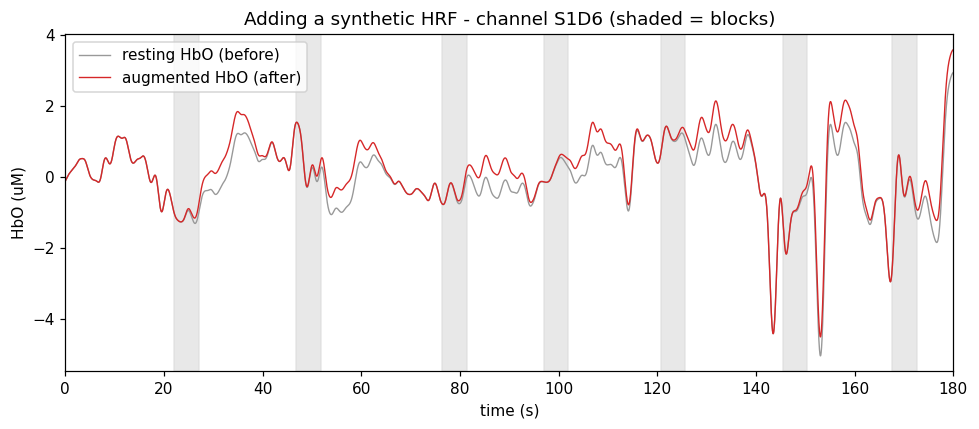

In [6]:
basis = glm.Gamma(tau=0 * units.s, sigma=3 * units.s, T=10 * units.s)
syn = synthetic_hrf.build_synthetic_hrf_timeseries(
    ts_long, stim_df, basis, spatial_pattern).sum("trial_type")
syn = syn.pint.quantify("micromolar")

ts_aug = ts_long + syn   # resting data + synthetic response

# show one active channel before/after
ch = active_channels[0]
t = ts_long.time.values
fig, ax = plt.subplots()
ax.plot(t, ts_long.sel(channel=ch, chromo="HbO").pint.magnitude,
        color="0.6", lw=0.9, label="resting HbO (before)")
ax.plot(t, ts_aug.sel(channel=ch, chromo="HbO").pint.magnitude,
        color="tab:red", lw=0.9, label="augmented HbO (after)")
for _, row in stim_df.iterrows():
    ax.axvspan(row.onset, row.onset + row.duration, color="0.85", alpha=0.6, zorder=0)
ax.set_xlim(0, 180)
ax.set_xlabel("time (s)"); ax.set_ylabel("HbO (uM)")
ax.set_title(f"Adding a synthetic HRF - channel {ch} (shaded = blocks)")
ax.legend(); plt.tight_layout(); plt.show()

## Step 5 - Recover it (closing the loop with NB3)

Running the **same block average** as NB3 on our augmented data recovers the
injected response on the active channels and leaves the inactive ones flat -
exactly the behaviour we saw with the dataset's own HRF files. This is the proof
that **augmentation + recovery** is a self-consistent way to validate a
pipeline.

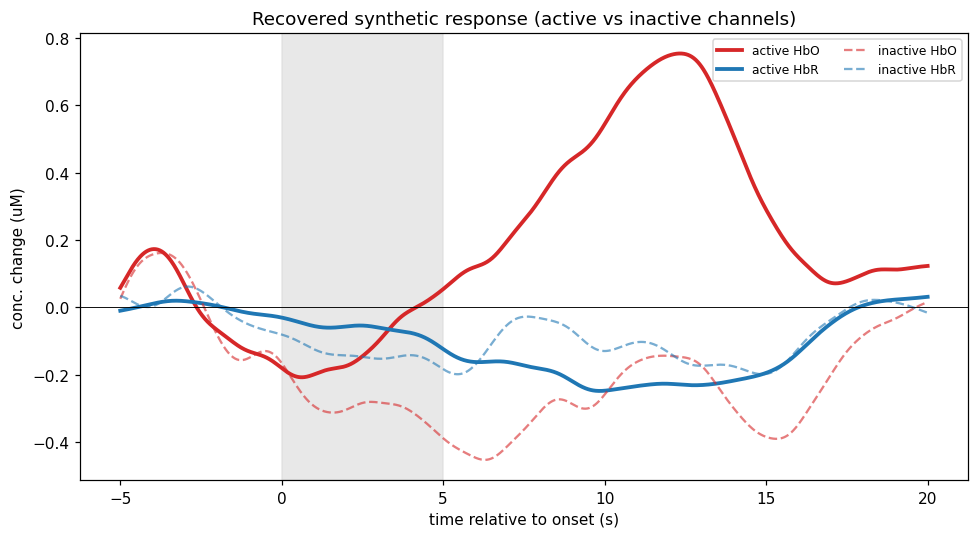

injected HbO amplitude : 0.66 uM

recovered HbO peak     : 0.54 uM   (block averaging recovers the injected amplitude closely)

In [7]:
inactive_channels = [str(c) for c in chans if str(c) not in active_channels]
ep = epochs.to_epochs(ts_aug, stim_df, ["Stim"],
                      before=5 * units.s, after=20 * units.s)
ba = (ep - ep.sel(reltime=slice(-5, 0)).mean("reltime")).mean("epoch")
rt = ba.reltime.values

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rt, ba.sel(channel=active_channels, chromo="HbO").mean("channel").pint.magnitude,
        color="tab:red", lw=2.5, label="active HbO")
ax.plot(rt, ba.sel(channel=active_channels, chromo="HbR").mean("channel").pint.magnitude,
        color="tab:blue", lw=2.5, label="active HbR")
ax.plot(rt, ba.sel(channel=inactive_channels, chromo="HbO").mean("channel").pint.magnitude,
        color="tab:red", lw=1.5, ls="--", alpha=0.6, label="inactive HbO")
ax.plot(rt, ba.sel(channel=inactive_channels, chromo="HbR").mean("channel").pint.magnitude,
        color="tab:blue", lw=1.5, ls="--", alpha=0.6, label="inactive HbR")
ax.axvspan(0, 5, color="0.85", alpha=0.6, zorder=0)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("time relative to onset (s)"); ax.set_ylabel("conc. change (uM)")
ax.set_title("Recovered synthetic response (active vs inactive channels)")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

peak = float(ba.sel(channel=active_channels, chromo="HbO").mean("channel")
             .sel(reltime=slice(4, 10)).max().pint.magnitude)
print(f"injected HbO amplitude : {HBO_AMP:.2f} uM")
print(f"recovered HbO peak     : {peak:.2f} uM   "
      f"(block averaging recovers the injected amplitude closely)")

## Beyond the basics

This simple recipe uses a single gamma HRF with a fixed amplitude. Real
augmentation pipelines go further:

- **Realistic HRF shapes** - e.g. a *triple-gamma* model with an initial dip and
  post-stimulus undershoot, with parameters drawn from distributions so every
  trial differs slightly.
- **Spectrally-matched noise** - using methods such as **FOOOF** to model the
  background 1/f + oscillatory spectrum so the synthetic data has realistic
  systemic physiology.
- **Image-space activation** - placing the response on the cortical surface and
  projecting it through the optical forward model, rather than directly on
  channels.

> The author's own `PJ00-RE-Synthetic-Data` project implements such an advanced
> generator (FOOOF-based noise + triple-gamma HRF), which is how the synthetic
> components in this course were designed.

## Takeaways

- `cedalion.sim.synthetic_hrf` turns any resting recording into a **ground-truth
  task dataset**: pick a design, a spatial pattern and an HRF, then add it.
- Recovering the injected response with the **same** block-average / GLM
  pipeline validates that the analysis works - the logic behind the
  `resting_hrf_*.snirf` files used in NB3.
- This underpins **method benchmarking** and **data augmentation** for fNIRS.